Data visualization

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from emg2qwerty.data import EMGSessionData

# Dataset root (same as in config: data/)
DATA_ROOT = Path("data")

# One session from the default single_user config (without .hdf5)
SESSION_ID = "2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f"
session_path = DATA_ROOT / f"{SESSION_ID}.hdf5"

if not session_path.exists():
    raise FileNotFoundError(f"Session not found: {session_path}. Download dataset and put HDF5s in data/.")

with EMGSessionData(session_path) as session:
    print(session)  # e.g. "EMGSessionData ...: (N samples, K keystrokes, X.XX mins)"
    print("Fields:", session.fields)  # ['emg_left', 'emg_right', 'time']

    # Load a short window (e.g. first 5 seconds at 2 kHz = 10_000 samples)
    n_samples = 10_000
    chunk = session[:n_samples]

    ts = chunk["time"]
    emg_left = chunk["emg_left"]   # (n_samples, 16)
    emg_right = chunk["emg_right"]  # (n_samples, 16)

    # Relative time in seconds for plotting
    t_sec = (ts - ts[0]) if len(ts) > 0 else np.array([])

EMGSessionData 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f: (1926629 EMG samples, 4667 keystrokes, 16.06 mins)
Fields: ['emg_right', 'time', 'emg_left']


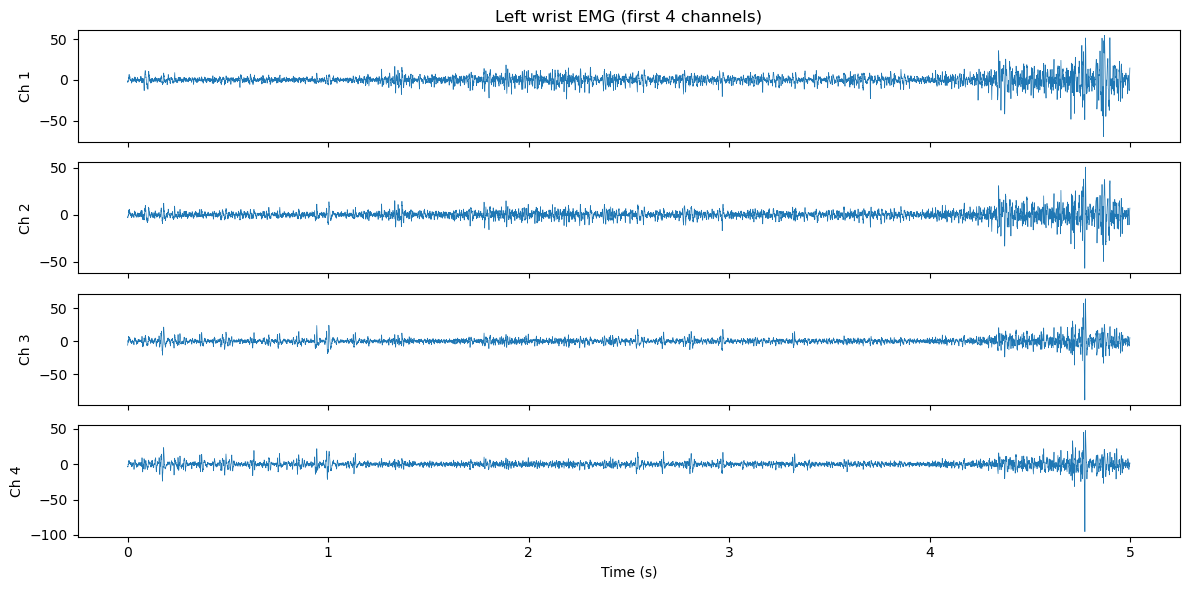

In [2]:
fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
for i in range(4):
    axes[i].plot(t_sec, emg_left[:, i], linewidth=0.5)
    axes[i].set_ylabel(f"Ch {i+1}")
axes[-1].set_xlabel("Time (s)")
axes[0].set_title("Left wrist EMG (first 4 channels)")
plt.tight_layout()
plt.show()

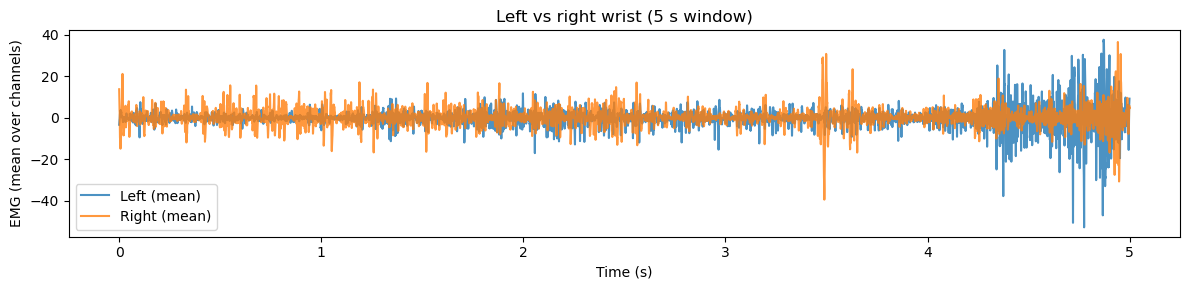

In [3]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_sec, emg_left.mean(axis=1), alpha=0.8, label="Left (mean)")
ax.plot(t_sec, emg_right.mean(axis=1), alpha=0.8, label="Right (mean)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("EMG (mean over channels)")
ax.legend()
ax.set_title("Left vs right wrist (5 s window)")
plt.tight_layout()
plt.show()

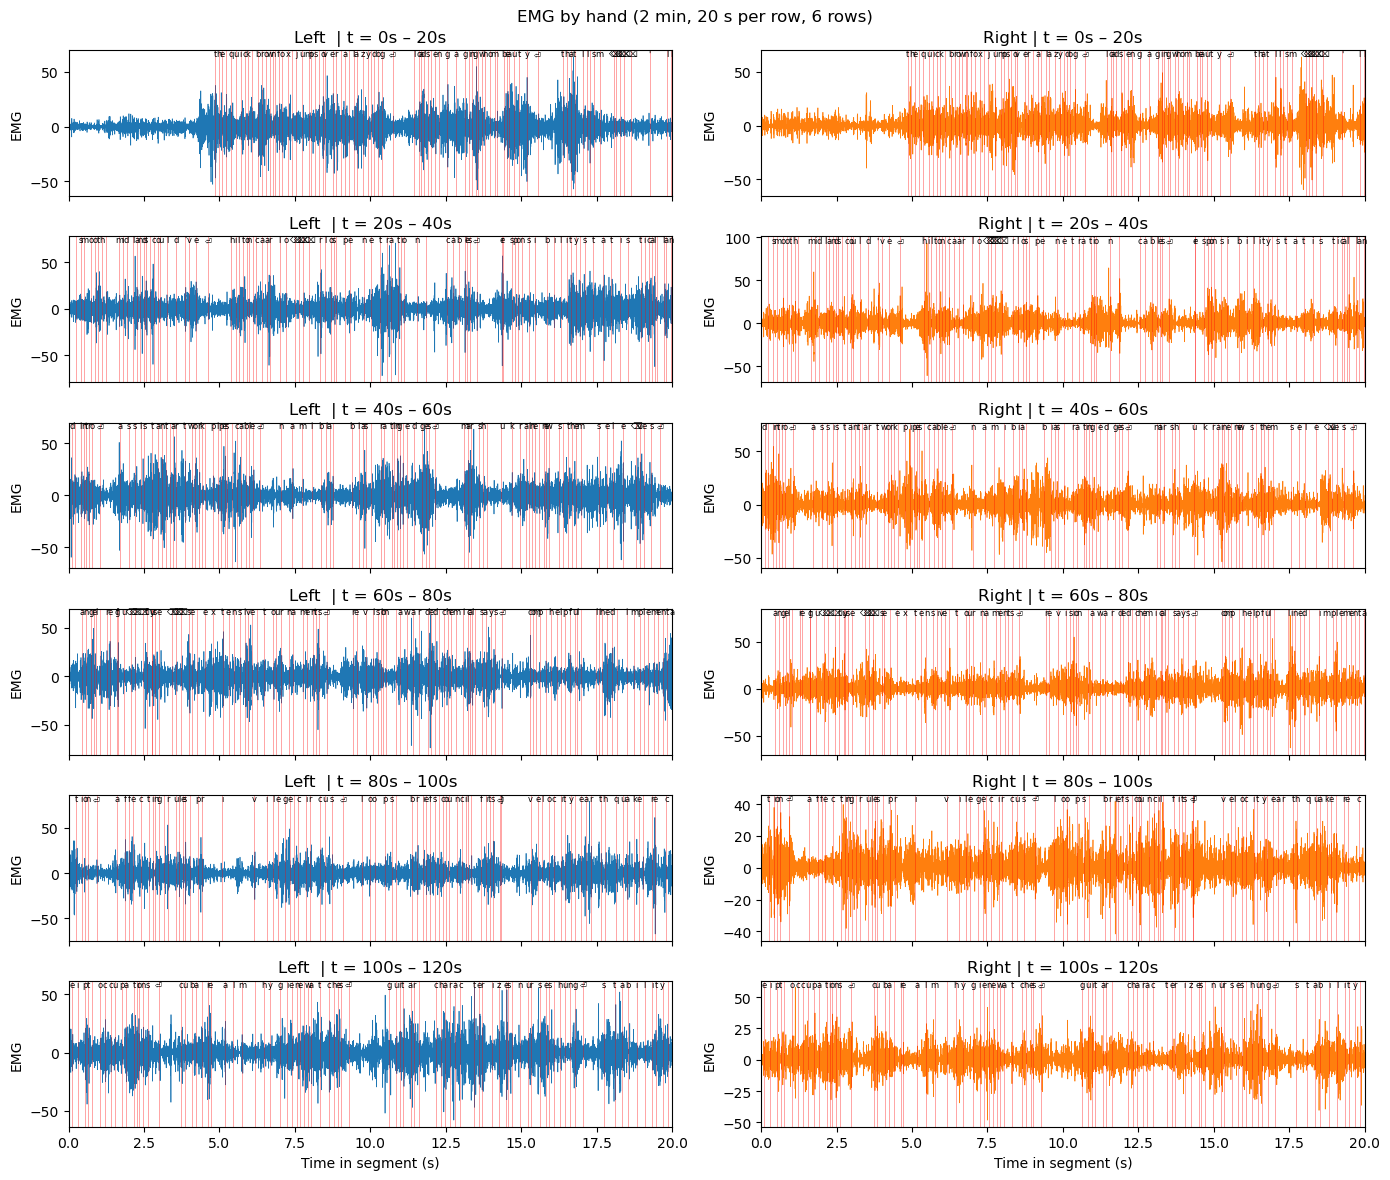

Typed text in window: "the quick brown fox jumps over a lazy dog⏎loads engaging whom beauty⏎thatll sm⌫⌫⌫⌫⌫'ll smooth midlands could've⏎hilton caarlo⌫⌫⌫⌫rlos penetration cables⏎responsibility statistical land intro⏎assistant"


In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from emg2qwerty.data import EMGSessionData

DATA_ROOT = Path("data")
SESSION_ID = "2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f"
session_path = DATA_ROOT / f"{SESSION_ID}.hdf5"

WINDOW_DURATION_SEC = 120   # 2 minutes
SEC_PER_ROW = 20
N_ROWS = 6

with EMGSessionData(session_path) as session:
    t0 = session.timeseries[session.TIMESTAMPS][0]
    t1 = t0 + WINDOW_DURATION_SEC
    gt = session.ground_truth(start_t=t0, end_t=t1)
    chunk = session.slice(start_t=t0, end_t=t1)
    ts = chunk["time"]
    emg_left = chunk["emg_left"].mean(axis=1)   # (T,) left wrist
    emg_right = chunk["emg_right"].mean(axis=1) # (T,) right wrist
    t_sec = ts - ts[0]

fig, axes = plt.subplots(N_ROWS, 2, figsize=(14, 2 * N_ROWS), sharex="col")
for row in range(N_ROWS):
    t_start = row * SEC_PER_ROW
    t_end = (row + 1) * SEC_PER_ROW
    mask = (t_sec >= t_start) & (t_sec < t_end)
    t_plot = t_sec[mask] - t_start

    # Left wrist
    axes[row, 0].plot(t_plot, emg_left[mask], linewidth=0.5, color="C0")
    if gt.timestamps is not None:
        for t, c in zip(gt.timestamps, gt.text):
            t_rel = t - t0
            if t_start <= t_rel < t_end:
                axes[row, 0].axvline(t_rel - t_start, color="red", alpha=0.5, linewidth=0.5)
                axes[row, 0].text(t_rel - t_start, axes[row, 0].get_ylim()[1] * 0.92, c, fontsize=6, ha="center")
    axes[row, 0].set_ylabel("EMG")
    axes[row, 0].set_xlim(0, SEC_PER_ROW)
    axes[row, 0].set_title(f"Left  | t = {t_start}s – {t_end}s")

    # Right wrist
    axes[row, 1].plot(t_plot, emg_right[mask], linewidth=0.5, color="C1")
    if gt.timestamps is not None:
        for t, c in zip(gt.timestamps, gt.text):
            t_rel = t - t0
            if t_start <= t_rel < t_end:
                axes[row, 1].axvline(t_rel - t_start, color="red", alpha=0.5, linewidth=0.5)
                axes[row, 1].text(t_rel - t_start, axes[row, 1].get_ylim()[1] * 0.92, c, fontsize=6, ha="center")
    axes[row, 1].set_ylabel("EMG")
    axes[row, 1].set_xlim(0, SEC_PER_ROW)
    axes[row, 1].set_title(f"Right | t = {t_start}s – {t_end}s")

axes[0, 0].set_title(f"Left  | t = 0s – {SEC_PER_ROW}s")
axes[0, 1].set_title(f"Right | t = 0s – {SEC_PER_ROW}s")
for row in range(1, N_ROWS):
    t_start = row * SEC_PER_ROW
    t_end = (row + 1) * SEC_PER_ROW
    axes[row, 0].set_title(f"Left  | t = {t_start}s – {t_end}s")
    axes[row, 1].set_title(f"Right | t = {t_start}s – {t_end}s")
axes[-1, 0].set_xlabel("Time in segment (s)")
axes[-1, 1].set_xlabel("Time in segment (s)")
fig.suptitle("EMG by hand (2 min, 20 s per row, 6 rows)", fontsize=12)
plt.tight_layout()
plt.show()
print("Typed text in window:", repr(gt.text[:200]))

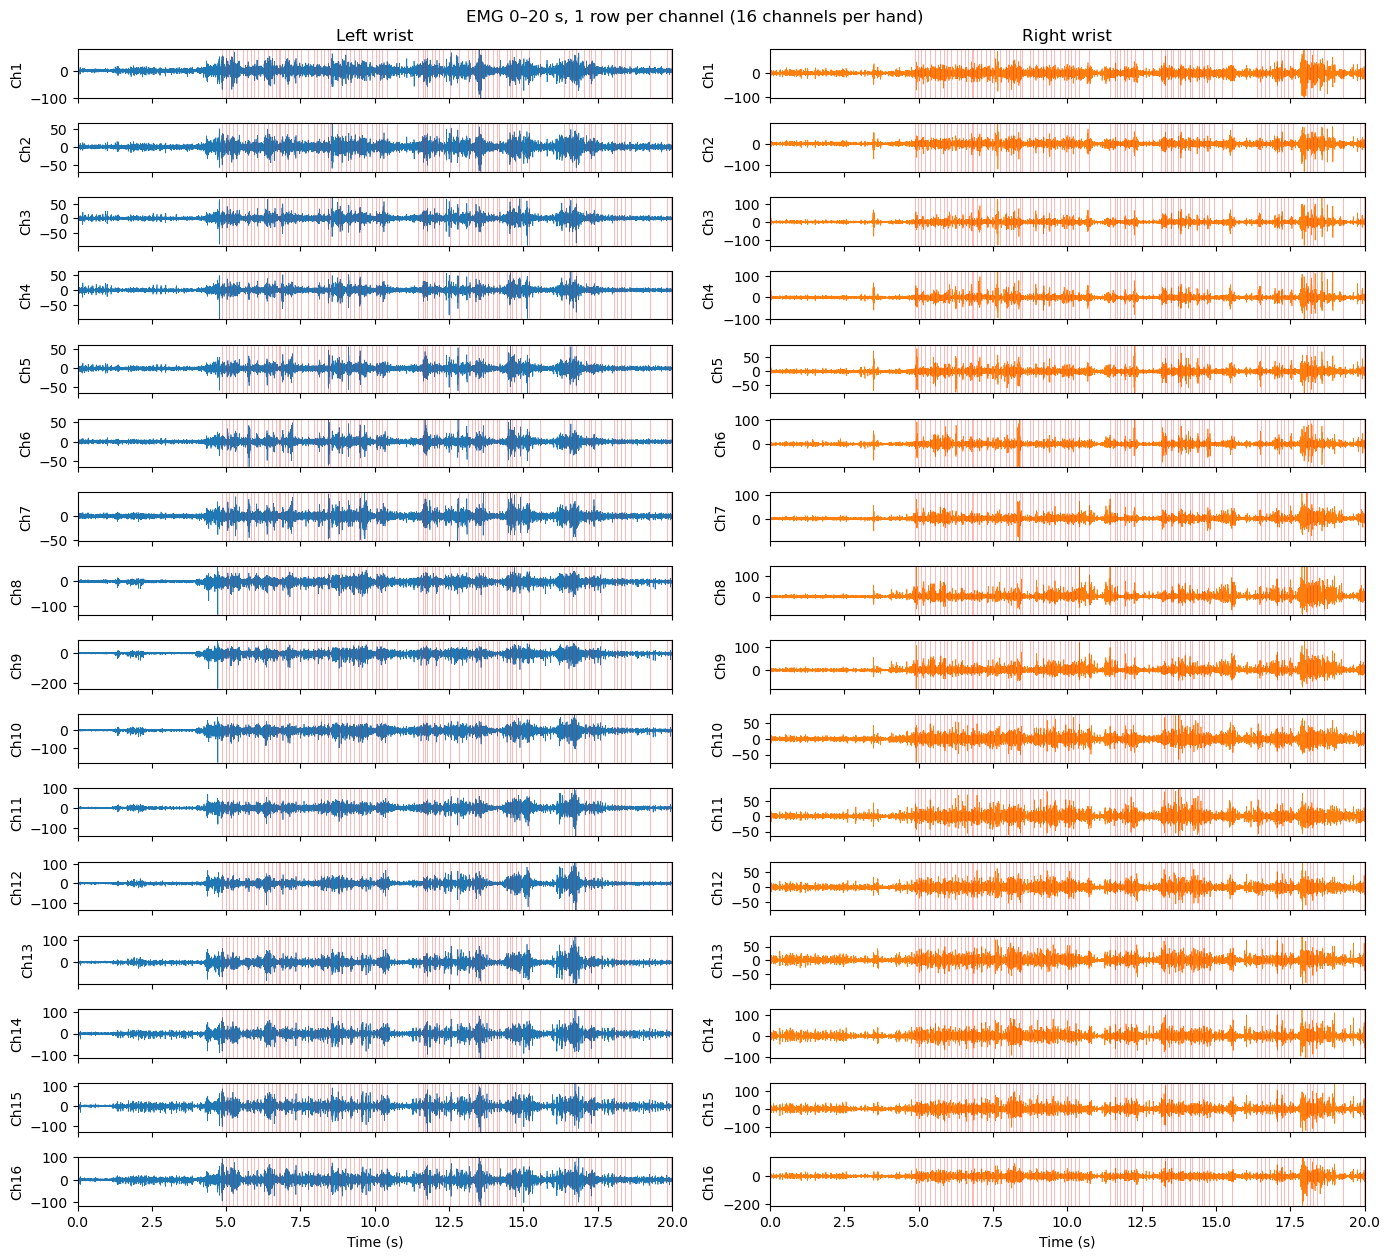

In [7]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from emg2qwerty.data import EMGSessionData

DATA_ROOT = Path("data")
SESSION_ID = "2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f"
session_path = DATA_ROOT / f"{SESSION_ID}.hdf5"

SEC_PER_ROW = 20
N_CHANNELS = 16   # dataset has 16 per hand; set to 8 to show first 8 only

with EMGSessionData(session_path) as session:
    t0 = session.timeseries[session.TIMESTAMPS][0]
    t1 = t0 + SEC_PER_ROW
    gt = session.ground_truth(start_t=t0, end_t=t1)
    chunk = session.slice(start_t=t0, end_t=t1)
    ts = chunk["time"]
    emg_left = chunk["emg_left"][:, :N_CHANNELS]   # (T, N_CHANNELS)
    emg_right = chunk["emg_right"][:, :N_CHANNELS]
    t_sec = ts - ts[0]

fig, axes = plt.subplots(N_CHANNELS, 2, figsize=(14, 0.8 * N_CHANNELS), sharex="col")
for ch in range(N_CHANNELS):
    # Left hand – one row per channel
    axes[ch, 0].plot(t_sec, emg_left[:, ch], linewidth=0.5, color="C0")
    if gt.timestamps is not None:
        for t, c in zip(gt.timestamps, gt.text):
            if t0 <= t < t1:
                axes[ch, 0].axvline(t - t0, color="red", alpha=0.4, linewidth=0.5)
    axes[ch, 0].set_ylabel(f"Ch{ch+1}")
    axes[ch, 0].set_xlim(0, SEC_PER_ROW)
    axes[ch, 0].set_ylim(emg_left[:, ch].min() - 1, emg_left[:, ch].max() + 1)

    # Right hand – one row per channel
    axes[ch, 1].plot(t_sec, emg_right[:, ch], linewidth=0.5, color="C1")
    if gt.timestamps is not None:
        for t, c in zip(gt.timestamps, gt.text):
            if t0 <= t < t1:
                axes[ch, 1].axvline(t - t0, color="red", alpha=0.4, linewidth=0.5)
    axes[ch, 1].set_ylabel(f"Ch{ch+1}")
    axes[ch, 1].set_xlim(0, SEC_PER_ROW)
    axes[ch, 1].set_ylim(emg_right[:, ch].min() - 1, emg_right[:, ch].max() + 1)

axes[0, 0].set_title("Left wrist")
axes[0, 1].set_title("Right wrist")
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle(f"EMG 0–20 s, 1 row per channel ({N_CHANNELS} channels per hand)", fontsize=12)
plt.tight_layout()
plt.show()

Correlated channels

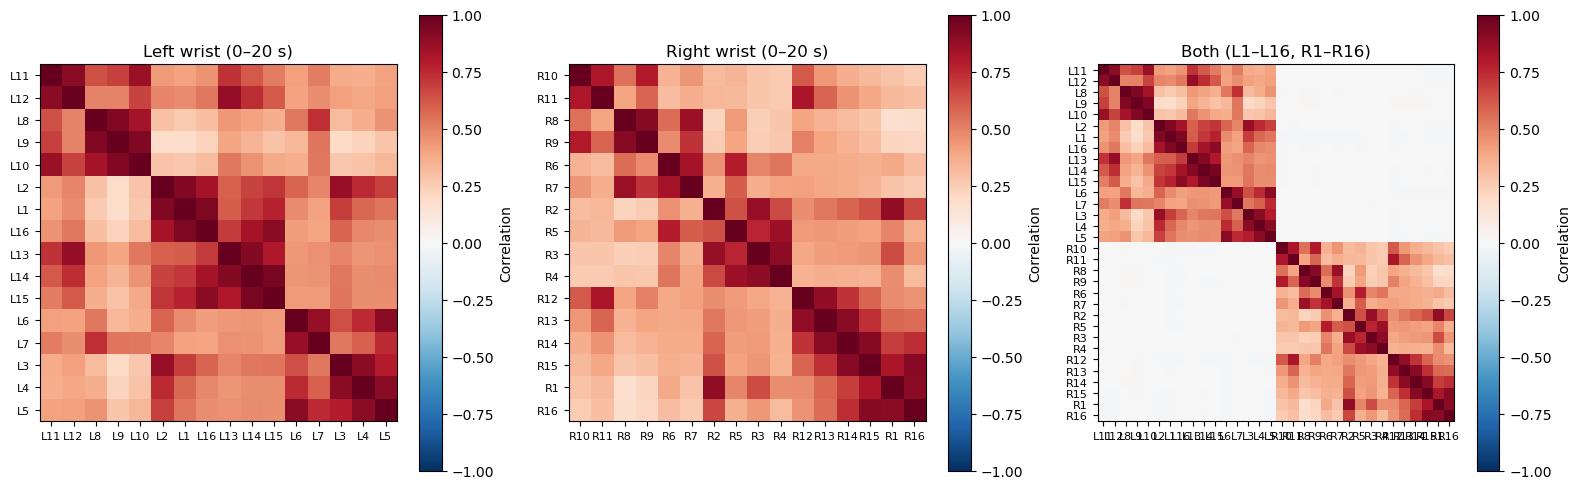

In [8]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from emg2qwerty.data import EMGSessionData

DATA_ROOT = Path("data")
SESSION_ID = "2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f"
session_path = DATA_ROOT / f"{SESSION_ID}.hdf5"

# Use 0-20 s (or longer for more stable correlations)
t_start, t_end = 0.0, 20.0

with EMGSessionData(session_path) as session:
    ts = session.timeseries[session.TIMESTAMPS]
    t0 = ts[0]
    start_idx = np.searchsorted(ts, t0 + t_start)
    end_idx = np.searchsorted(ts, t0 + t_end)
    chunk = session[start_idx:end_idx]
    left = chunk["emg_left"]   # (T, 16)
    right = chunk["emg_right"] # (T, 16)

# Correlation matrices (Pearson)
R_left = np.corrcoef(left.T)   # (16, 16)
R_right = np.corrcoef(right.T)
# Combined: rows/cols = [L1..L16, R1..R16]
both = np.hstack([left, right])  # (T, 32)
R_both = np.corrcoef(both.T)    # (32, 32)

def reorder_by_clustering(R):
    """Reorder channels so correlated ones are adjacent (1 - |r| as distance)."""
    np.fill_diagonal(R, 1)
    dist = 1 - np.abs(R)
    dist = (dist + dist.T) / 2
    np.fill_diagonal(dist, 0)
    cond = squareform(dist, checks=False)
    Z = linkage(cond, method="average")
    return leaves_list(Z)

def plot_corr_heatmap(R, labels, ax, title, vmin=-1, vmax=1):
    order = reorder_by_clustering(R.copy())
    R_ord = R[np.ix_(order, order)]
    lab_ord = [labels[i] for i in order]
    im = ax.imshow(R_ord, cmap="RdBu_r", vmin=vmin, vmax=vmax, aspect="equal")
    ax.set_xticks(range(len(lab_ord)))
    ax.set_yticks(range(len(lab_ord)))
    ax.set_xticklabels(lab_ord, fontsize=8)
    ax.set_yticklabels(lab_ord, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="Correlation")
    return order, R_ord

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels_left = [f"L{i+1}" for i in range(16)]
labels_right = [f"R{i+1}" for i in range(16)]
labels_both = labels_left + labels_right

order_l, _ = plot_corr_heatmap(R_left, labels_left, axes[0], "Left wrist (0–20 s)")
order_r, _ = plot_corr_heatmap(R_right, labels_right, axes[1], "Right wrist (0–20 s)")
order_b, _ = plot_corr_heatmap(R_both, labels_both, axes[2], "Both (L1–L16, R1–R16)")

plt.tight_layout()
plt.show()

In [10]:
def top_correlated_pairs(R, labels, n=10):
    # Upper triangle only so each pair appears once (R is symmetric)
    i_upper, j_upper = np.triu_indices_from(R, k=1)
    vals = R[i_upper, j_upper]
    order = np.argsort(np.abs(vals))[::-1]
    pairs = []
    for idx in order[:n]:
        i, j = i_upper[idx], j_upper[idx]
        pairs.append((labels[i], labels[j], R[i, j]))
    return pairs

print("Left wrist – top 10 |r|:")
for a, b, r in top_correlated_pairs(R_left, labels_left):
    print(f"  {a}–{b}: {r:.3f}")
print("\nRight wrist – top 10 |r|:")
for a, b, r in top_correlated_pairs(R_right, labels_right):
    print(f"  {a}–{b}: {r:.3f}")

Left wrist – top 10 |r|:
  L14–L15: 0.950
  L1–L16: 0.934
  L1–L2: 0.929
  L9–L10: 0.928
  L8–L9: 0.922
  L13–L14: 0.919
  L4–L5: 0.906
  L15–L16: 0.905
  L3–L4: 0.903
  L11–L12: 0.903

Right wrist – top 10 |r|:
  R14–R15: 0.914
  R8–R9: 0.912
  R15–R16: 0.911
  R1–R16: 0.905
  R13–R14: 0.900
  R3–R4: 0.898
  R12–R13: 0.887
  R1–R2: 0.887
  R2–R3: 0.869
  R7–R8: 0.858


In [20]:
for path in session_paths:
    with EMGSessionData(path) as session:
        print(f"{path.stem[:50]:50s}  {session.duration_mins:.2f} min")

2021-06-03-1622765527-keystrokes-dca-study@1-0efbe  16.06 min
2021-06-02-1622681518-keystrokes-dca-study@1-0efbe  18.07 min
2021-06-04-1622863166-keystrokes-dca-study@1-0efbe  14.92 min
2021-07-22-1627003020-keystrokes-dca-study@1-0efbe  15.15 min
2021-07-21-1626916256-keystrokes-dca-study@1-0efbe  15.13 min
2021-07-22-1627004019-keystrokes-dca-study@1-0efbe  14.92 min
2021-06-05-1622885888-keystrokes-dca-study@1-0efbe  17.36 min
2021-06-02-1622679967-keystrokes-dca-study@1-0efbe  19.81 min
2021-06-03-1622764398-keystrokes-dca-study@1-0efbe  15.61 min
2021-07-21-1626917264-keystrokes-dca-study@1-0efbe  14.66 min
2021-06-05-1622889105-keystrokes-dca-study@1-0efbe  16.96 min
2021-06-03-1622766673-keystrokes-dca-study@1-0efbe  15.62 min
2021-06-04-1622861066-keystrokes-dca-study@1-0efbe  14.93 min
2021-07-22-1627001995-keystrokes-dca-study@1-0efbe  14.55 min
2021-06-05-1622884635-keystrokes-dca-study@1-0efbe  17.75 min
2021-07-21-1626915176-keystrokes-dca-study@1-0efbe  14.52 min
2021-06-

In [12]:
# --- All sessions: load list from config ---
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml
from emg2qwerty.data import EMGSessionData

DATA_ROOT = Path("data")
CONFIG_PATH = Path("config/user/single_user.yaml")

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)
sessions = []
for split in ("train", "val", "test"):
    for entry in config["dataset"][split]:
        sessions.append(entry["session"])
session_paths = [DATA_ROOT / f"{s}.hdf5" for s in sessions]
# Optional: only use sessions that exist
session_paths = [p for p in session_paths if p.exists()]
print(f"Using {len(session_paths)} sessions")

Using 18 sessions


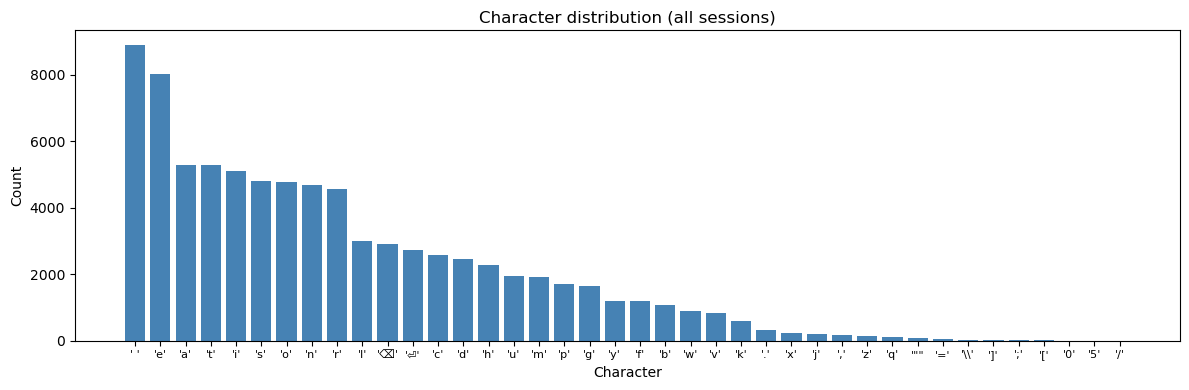

In [13]:
from collections import Counter
char_counts = Counter()
for path in session_paths:
    with EMGSessionData(path) as session:
        gt = session.ground_truth()
        char_counts.update(gt.text)
chars = list(char_counts.keys())
counts = np.array([char_counts[c] for c in chars])
order = np.argsort(counts)[::-1]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(chars)), counts[order], color="steelblue", edgecolor="none")
ax.set_xticks(range(len(chars)))
ax.set_xticklabels([repr(chars[i]) for i in order], fontsize=8)
ax.set_xlabel("Character")
ax.set_ylabel("Count")
ax.set_title("Character distribution (all sessions)")
plt.tight_layout()
plt.show()

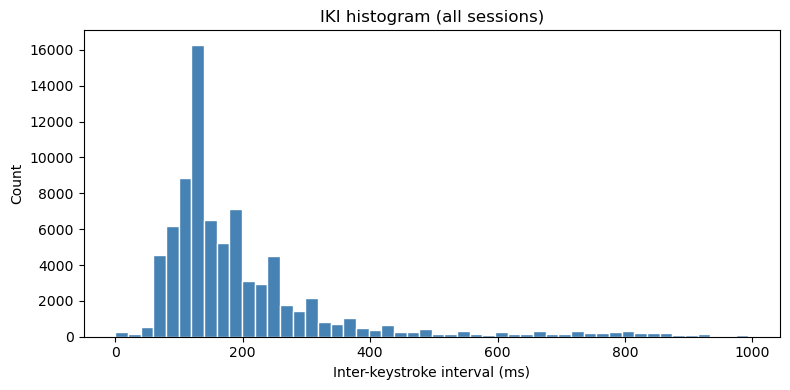

In [14]:
iki_all = []
for path in session_paths:
    with EMGSessionData(path) as session:
        ks = session.keystrokes
        if len(ks) < 2:
            continue
        starts = np.array([k["start"] for k in ks])
        iki_ms = (np.diff(starts) * 1000)
        iki_ms = iki_ms[(iki_ms > 0) & (iki_ms < 1000)]
        iki_all.append(iki_ms)
iki_all = np.concatenate(iki_all) if iki_all else np.array([])
if len(iki_all) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(iki_all, bins=50, color="steelblue", edgecolor="white")
    ax.set_xlabel("Inter-keystroke interval (ms)")
    ax.set_ylabel("Count")
    ax.set_title("IKI histogram (all sessions)")
    plt.tight_layout()
    plt.show()

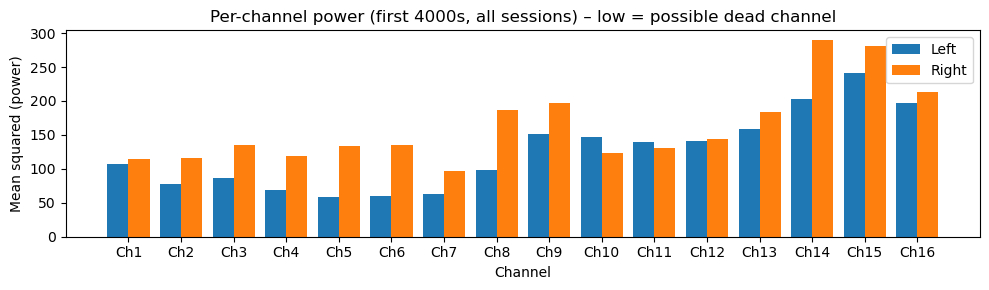

In [21]:
# Replace the 4-panel mean/std with: variance per channel (spot dead/low-power channels)
WIN_SEC = 4000
var_l, var_r = [], []
for path in session_paths:
    with EMGSessionData(path) as session:
        t0 = session.timeseries[session.TIMESTAMPS][0]
        chunk = session.slice(start_t=t0, end_t=t0 + WIN_SEC)
        if len(chunk) == 0:
            continue
        var_l.append((chunk["emg_left"] ** 2).mean(axis=0))
        var_r.append((chunk["emg_right"] ** 2).mean(axis=0))
var_l = np.array(var_l).mean(axis=0)
var_r = np.array(var_r).mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 3))
x = np.arange(16)
ax.bar(x - 0.2, var_l, 0.4, label="Left", color="C0")
ax.bar(x + 0.2, var_r, 0.4, label="Right", color="C1")
ax.set_xlabel("Channel")
ax.set_ylabel("Mean squared (power)")
ax.set_xticks(x)
ax.set_xticklabels([f"Ch{i+1}" for i in range(16)])
ax.legend()
ax.set_title("Per-channel power (first 4000s, all sessions) – low = possible dead channel")
plt.tight_layout()
plt.show()

In [25]:
WIN_SEC = 4000
mins_l, maxs_l = [], []
mins_r, maxs_r = [], []
for path in session_paths:
    with EMGSessionData(path) as session:
        t0 = session.timeseries[session.TIMESTAMPS][0]
        chunk = session.slice(start_t=t0, end_t=t0 + WIN_SEC)
        if len(chunk) == 0:
            continue
        mins_l.append(chunk["emg_left"].min(axis=0))
        maxs_l.append(chunk["emg_left"].max(axis=0))
        mins_r.append(chunk["emg_right"].min(axis=0))
        maxs_r.append(chunk["emg_right"].max(axis=0))

# Stack and take worst-case per channel across sessions
min_l = np.array(mins_l).min(axis=0)
max_l = np.array(maxs_l).max(axis=0)
min_r = np.array(mins_r).min(axis=0)
max_r = np.array(maxs_r).max(axis=0)

In [26]:
import pandas as pd
df = pd.DataFrame({
    "channel": [f"L{i+1}" for i in range(16)] + [f"R{i+1}" for i in range(16)],
    "min": np.hstack([min_l, min_r]),
    "max": np.hstack([max_l, max_r]),
})
print(df.to_string(index=False))

channel          min         max
     L1  -259.831696  230.590027
     L2  -433.169495  384.623230
     L3  -333.162506  260.035461
     L4  -247.849014  192.190277
     L5  -283.864990  253.845764
     L6  -308.892303  290.899353
     L7  -267.497681  248.215439
     L8  -309.526276  268.780823
     L9  -296.275177  172.083725
    L10  -316.518097  222.421906
    L11  -316.590515  234.894882
    L12  -330.857849  286.586517
    L13  -303.122955  292.755310
    L14  -315.635986  314.581970
    L15 -1410.507446 2193.772705
    L16  -469.205902  340.582672
     R1  -352.585602  385.694336
     R2  -295.122101  224.360596
     R3  -434.004059  355.570709
     R4  -485.626190  419.756989
     R5  -441.904327  400.347412
     R6  -603.456299  469.503906
     R7  -375.303406  300.250610
     R8  -357.063995  518.081909
     R9  -498.869476  468.160156
    R10  -174.413773  295.910583
    R11  -269.821716  297.439972
    R12  -244.030350  329.301941
    R13  -244.903091  281.379974
    R14  -

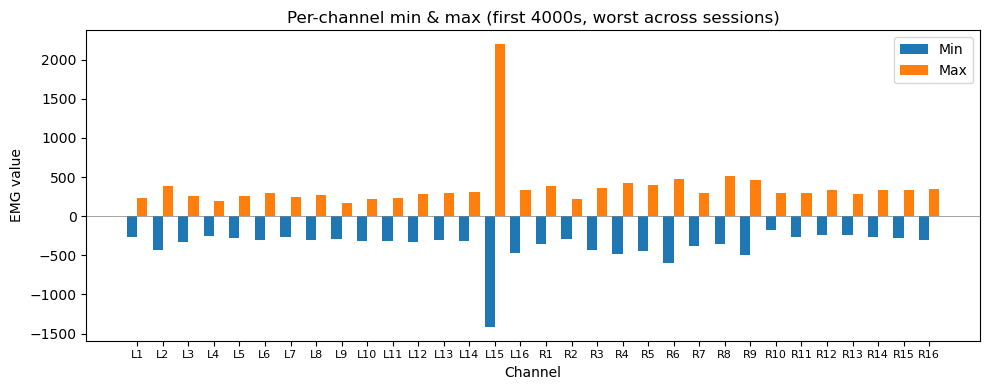

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(32)
labels = [f"L{i+1}" for i in range(16)] + [f"R{i+1}" for i in range(16)]
ax.bar(x - 0.2, df["min"], 0.4, label="Min", color="C0")
ax.bar(x + 0.2, df["max"], 0.4, label="Max", color="C1")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("EMG value")
ax.set_xlabel("Channel")
ax.legend()
ax.set_title("Per-channel min & max (first 4000s, worst across sessions)")
plt.tight_layout()
plt.show()

In [28]:
from pathlib import Path
import numpy as np
import yaml
from emg2qwerty.data import EMGSessionData

DATA_ROOT = Path("data")
CONFIG_PATH = Path("config/user/single_user.yaml")
WIN_SEC = 60  # fixed window for EMG summary

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)
train_sessions = [entry["session"] for entry in config["dataset"]["train"]]
session_paths = [DATA_ROOT / f"{s}.hdf5" for s in train_sessions]
session_paths = [p for p in session_paths if p.exists()]

def session_summary(path):
    with EMGSessionData(path) as session:
        t0 = session.timeseries[session.TIMESTAMPS][0]
        chunk = session.slice(start_t=t0, end_t=t0 + WIN_SEC)
        n_ks = len(session.keystrokes)
        dur = session.duration_mins
        if len(chunk) == 0:
            return None, None
        left = chunk["emg_left"]   # (T, 16)
        right = chunk["emg_right"]
        # Per-channel mean and std -> 32 + 32 = 64 values
        feat = np.hstack([left.mean(axis=0), left.std(axis=0), right.mean(axis=0), right.std(axis=0)])
        meta = np.array([dur, n_ks])
    return feat, meta

names = [p.stem[:45] for p in session_paths]
features = []
meta_list = []
for path in session_paths:
    feat, meta = session_summary(path)
    if feat is not None:
        features.append(feat)
        meta_list.append(meta)
X = np.array(features)
M = np.array(meta_list)
# Standardize so correlation/distance is on comparable scale
X_norm = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

In [29]:
# Session-session correlation (rows = sessions)
R = np.corrcoef(X_norm)
np.fill_diagonal(R, np.nan)  # ignore self
n = len(names)

In [30]:
# Upper triangle only, avoid duplicate
iu = np.triu_indices(n, k=1)
pairs = [(i, j, R[i, j]) for i, j in zip(iu[0], iu[1])]
pairs.sort(key=lambda x: -x[2])
print("Most similar training sessions (by EMG summary correlation):")
for i, j, r in pairs[:10]:
    print(f"  {r:.3f}  {names[i]}")
    print(f"       {names[j]}")

Most similar training sessions (by EMG summary correlation):
  0.813  2021-06-05-1622885888-keystrokes-dca-study@1-
       2021-06-05-1622884635-keystrokes-dca-study@1-
  0.686  2021-07-22-1627003020-keystrokes-dca-study@1-
       2021-07-22-1627004019-keystrokes-dca-study@1-
  0.655  2021-07-22-1627004019-keystrokes-dca-study@1-
       2021-07-22-1627001995-keystrokes-dca-study@1-
  0.646  2021-06-05-1622885888-keystrokes-dca-study@1-
       2021-06-05-1622889105-keystrokes-dca-study@1-
  0.577  2021-06-05-1622889105-keystrokes-dca-study@1-
       2021-06-05-1622884635-keystrokes-dca-study@1-
  0.567  2021-07-22-1627003020-keystrokes-dca-study@1-
       2021-07-22-1627001995-keystrokes-dca-study@1-
  0.506  2021-06-03-1622765527-keystrokes-dca-study@1-
       2021-06-02-1622679967-keystrokes-dca-study@1-
  0.503  2021-07-22-1627004019-keystrokes-dca-study@1-
       2021-06-04-1622861066-keystrokes-dca-study@1-
  0.493  2021-06-05-1622885888-keystrokes-dca-study@1-
       2021-06-03-16

EMG similarity across sessions

In [32]:
def session_summary_full(path, chunk_sec=60):
    """Per-channel mean and std over the entire session (chunked for memory)."""
    with EMGSessionData(path) as session:
        n_samples = len(session)
        ts = session.timeseries[session.TIMESTAMPS]
        t0, t_end = ts[0], ts[-1]
        n_ch = 16
        sum_l = np.zeros(n_ch)
        sum_r = np.zeros(n_ch)
        sum_sq_l = np.zeros(n_ch)
        sum_sq_r = np.zeros(n_ch)
        n = 0
        t = t0
        while t < t_end:
            chunk = session.slice(start_t=t, end_t=min(t + chunk_sec, t_end))
            if len(chunk) == 0:
                break
            left = chunk["emg_left"]
            right = chunk["emg_right"]
            sum_l += left.sum(axis=0)
            sum_r += right.sum(axis=0)
            sum_sq_l += (left ** 2).sum(axis=0)
            sum_sq_r += (right ** 2).sum(axis=0)
            n += len(chunk)
            t += chunk_sec
        if n == 0:
            return None, None
        mean_l = sum_l / n
        mean_r = sum_r / n
        var_l = sum_sq_l / n - mean_l ** 2
        var_r = sum_sq_r / n - mean_r ** 2
        std_l = np.sqrt(np.maximum(var_l, 0))
        std_r = np.sqrt(np.maximum(var_r, 0))
        feat = np.hstack([mean_l, std_l, mean_r, std_r])
        meta = np.array([session.duration_mins, len(session.keystrokes)])
    return feat, meta

In [33]:
names = [p.stem[:45] for p in session_paths]
features = []
meta_list = []
for path in session_paths:
    feat, meta = session_summary_full(path)
    if feat is not None:
        features.append(feat)
        meta_list.append(meta)
X = np.array(features)
M = np.array(meta_list)
X_norm = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
R = np.corrcoef(X_norm)
np.fill_diagonal(R, np.nan)
n = len(names)

In [34]:
iu = np.triu_indices(n, k=1)
pairs = [(i, j, R[i, j]) for i, j in zip(iu[0], iu[1])]
pairs.sort(key=lambda x: -x[2])
print("Most similar (full-session EMG summary):")
for i, j, r in pairs[:10]:
    print(f"  {r:.3f}  {names[i]}")
    print(f"       {names[j]}")

Most similar (full-session EMG summary):
  0.931  2021-07-21-1626916256-keystrokes-dca-study@1-
       2021-07-21-1626917264-keystrokes-dca-study@1-
  0.913  2021-06-03-1622765527-keystrokes-dca-study@1-
       2021-06-03-1622766673-keystrokes-dca-study@1-
  0.832  2021-06-05-1622885888-keystrokes-dca-study@1-
       2021-06-05-1622884635-keystrokes-dca-study@1-
  0.830  2021-07-22-1627004019-keystrokes-dca-study@1-
       2021-07-22-1627001995-keystrokes-dca-study@1-
  0.738  2021-06-05-1622889105-keystrokes-dca-study@1-
       2021-06-05-1622884635-keystrokes-dca-study@1-
  0.735  2021-06-05-1622885888-keystrokes-dca-study@1-
       2021-06-05-1622889105-keystrokes-dca-study@1-
  0.719  2021-06-03-1622764398-keystrokes-dca-study@1-
       2021-06-03-1622766673-keystrokes-dca-study@1-
  0.654  2021-06-03-1622765527-keystrokes-dca-study@1-
       2021-06-03-1622764398-keystrokes-dca-study@1-
  0.619  2021-06-05-1622885888-keystrokes-dca-study@1-
       2021-06-03-1622766673-keystrokes-

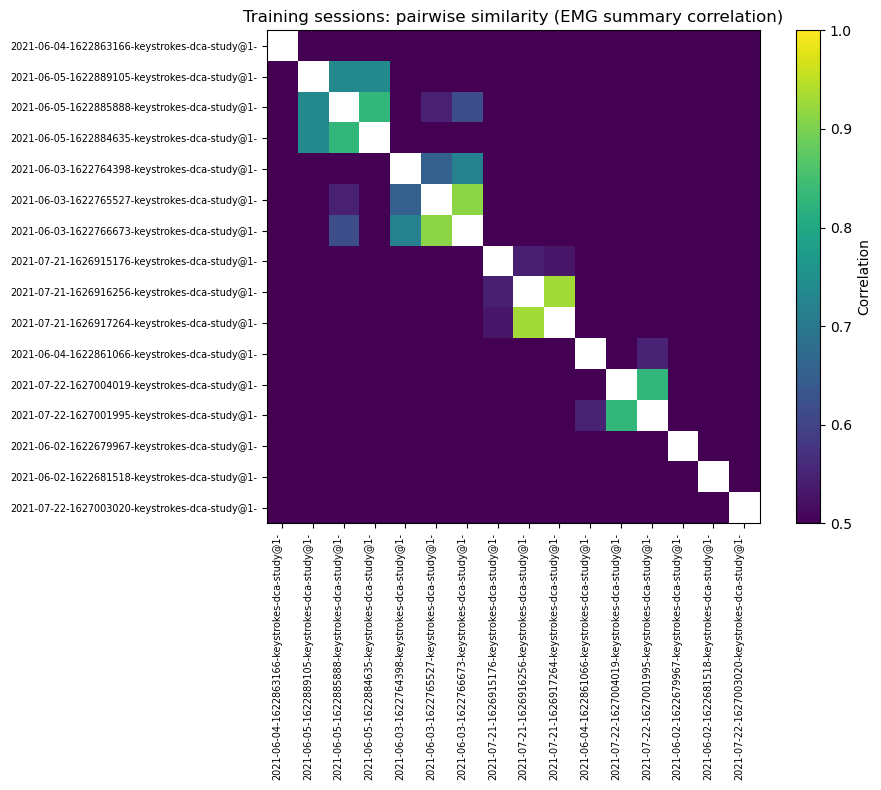

In [35]:
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import pdist, squareform

# Use 1 - correlation as distance (so similar = small distance)
dist = 1 - R
dist = (dist + dist.T) / 2
np.fill_diagonal(dist, 0)
condensed = squareform(dist, checks=False)
Z = linkage(condensed, method="average")
order = leaves_list(Z)
R_ord = R[np.ix_(order, order)]
names_ord = [names[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(R_ord, cmap="viridis", vmin=0.5, vmax=1, aspect="equal")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(names_ord, rotation=90, ha="right", fontsize=7)
ax.set_yticklabels(names_ord, fontsize=7)
ax.set_title("Training sessions: pairwise similarity (EMG summary correlation)")
plt.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

Keystroke similarity across sessions

Most similar by keystroke (character distribution):
  0.386  2021-07-22-1627003020-keystrokes-dca-study@1-
       2021-06-04-1622861066-keystrokes-dca-study@1-
  0.369  2021-07-22-1627004019-keystrokes-dca-study@1-
       2021-07-21-1626917264-keystrokes-dca-study@1-
  0.342  2021-06-02-1622679967-keystrokes-dca-study@1-
       2021-06-04-1622861066-keystrokes-dca-study@1-
  0.324  2021-07-22-1627003020-keystrokes-dca-study@1-
       2021-06-03-1622766673-keystrokes-dca-study@1-
  0.277  2021-07-21-1626917264-keystrokes-dca-study@1-
       2021-07-21-1626915176-keystrokes-dca-study@1-
  0.275  2021-06-02-1622681518-keystrokes-dca-study@1-
       2021-07-21-1626916256-keystrokes-dca-study@1-
  0.272  2021-06-02-1622679967-keystrokes-dca-study@1-
       2021-06-05-1622884635-keystrokes-dca-study@1-
  0.270  2021-07-22-1627001995-keystrokes-dca-study@1-
       2021-07-21-1626915176-keystrokes-dca-study@1-
  0.257  2021-06-03-1622765527-keystrokes-dca-study@1-
       2021-06-03-1622764398-

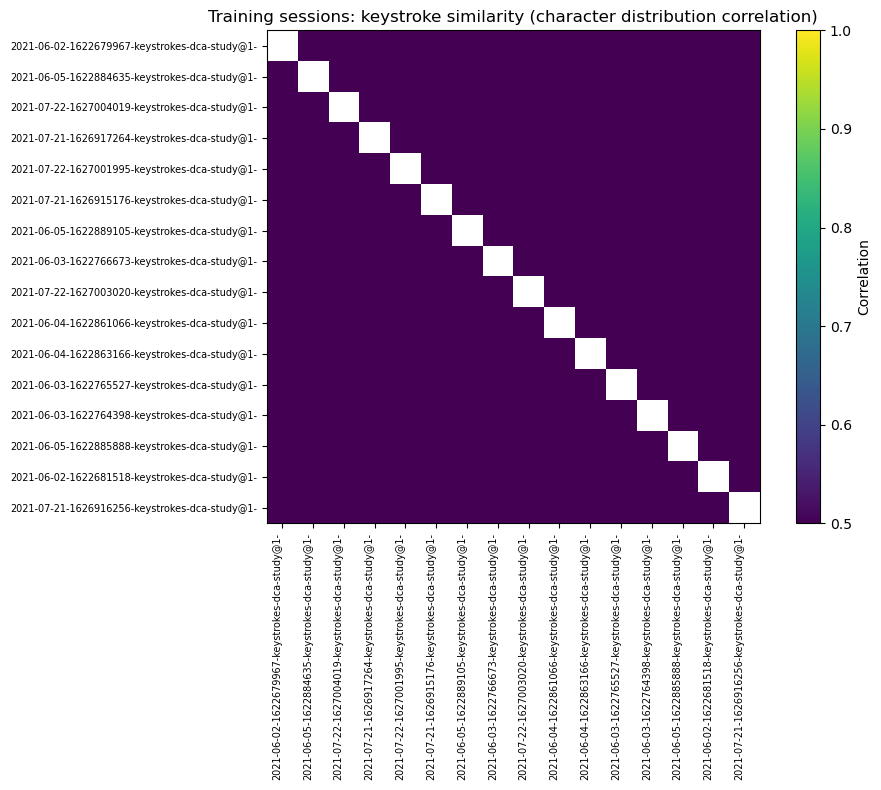

Most similar by EMG + keystroke combined:
  0.546  2021-06-03-1622765527-keystrokes-dca-study@1-
       2021-06-03-1622766673-keystrokes-dca-study@1-
  0.510  2021-07-22-1627004019-keystrokes-dca-study@1-
       2021-07-22-1627001995-keystrokes-dca-study@1-
  0.493  2021-06-03-1622765527-keystrokes-dca-study@1-
       2021-06-03-1622764398-keystrokes-dca-study@1-
  0.475  2021-06-03-1622764398-keystrokes-dca-study@1-
       2021-06-03-1622766673-keystrokes-dca-study@1-
  0.416  2021-07-21-1626917264-keystrokes-dca-study@1-
       2021-07-21-1626915176-keystrokes-dca-study@1-
  0.344  2021-06-04-1622861066-keystrokes-dca-study@1-
       2021-07-22-1627001995-keystrokes-dca-study@1-
  0.335  2021-07-22-1627003020-keystrokes-dca-study@1-
       2021-07-21-1626916256-keystrokes-dca-study@1-
  0.333  2021-06-03-1622765527-keystrokes-dca-study@1-
       2021-06-05-1622885888-keystrokes-dca-study@1-
  0.321  2021-06-05-1622885888-keystrokes-dca-study@1-
       2021-06-05-1622889105-keystrokes

In [41]:
from collections import Counter
from emg2qwerty.charset import charset

cs = charset()
# Fixed ordering: characters in the same order as the model's charset
char_order = list(cs.allowed_chars)

def keystroke_summary(path):
    """Character count vector over full session (same order as charset)."""
    with EMGSessionData(path) as session:
        gt = session.ground_truth()
        counts = Counter(gt.text)
    vec = np.array([counts.get(c, 0) for c in char_order], dtype=float)
    return vec

# Build keystroke feature matrix
K = np.array([keystroke_summary(p) for p in session_paths])
K_std = (K - K.mean(axis=0)) / (K.std(axis=0) + 1e-8)
R_keystroke = np.corrcoef(K_std)
np.fill_diagonal(R_keystroke, np.nan)
n = len(names)

# Top pairs by keystroke similarity
iu = np.triu_indices(n, k=1)
pairs_ks = [(i, j, R_keystroke[i, j]) for i, j in zip(iu[0], iu[1])]
pairs_ks.sort(key=lambda x: -x[2])
print("Most similar by keystroke (character distribution):")
for i, j, r in pairs_ks[:10]:
    print(f"  {r:.3f}  {names[i]}")
    print(f"       {names[j]}")

# Optional: heatmap for keystroke similarity
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

dist_ks = 1 - R_keystroke
np.fill_diagonal(dist_ks, 0)
dist_ks = (dist_ks + dist_ks.T) / 2
Z_ks = linkage(squareform(dist_ks, checks=False), method="average")
order_ks = leaves_list(Z_ks)
R_ks_ord = R_keystroke[np.ix_(order_ks, order_ks)]
names_ks_ord = [names[i] for i in order_ks]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(R_ks_ord, cmap="viridis", vmin=0.5, vmax=1, aspect="equal")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(names_ks_ord, rotation=90, ha="right", fontsize=7)
ax.set_yticklabels(names_ks_ord, fontsize=7)
ax.set_title("Training sessions: keystroke similarity (character distribution correlation)")
plt.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

# Optional: combined EMG + keystroke similarity
combined = np.hstack([X_norm, K_std])
R_combined = np.corrcoef(combined)
np.fill_diagonal(R_combined, np.nan)
pairs_comb = [(i, j, R_combined[i, j]) for i, j in zip(iu[0], iu[1])]
pairs_comb.sort(key=lambda x: -x[2])
print("Most similar by EMG + keystroke combined:")
for i, j, r in pairs_comb[:10]:
    print(f"  {r:.3f}  {names[i]}")
    print(f"       {names[j]}")